# Decomposition Results: TFIM vs Naive vs Trotter

## Load data

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find Results/ whether this notebook runs from Results/ or the repo root
results_dir = os.getcwd()
if os.path.basename(results_dir) != "Results" and os.path.isdir("Results"):
    results_dir = os.path.abspath("Results")

def load(name):
    path = os.path.join(results_dir, name)
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f"(missing) {name}")
        return None
    df = pd.read_csv(path, skipinitialspace=True, na_values=["N/A"])
    df.columns = df.columns.str.strip()
    # append-mode files can accumulate duplicates across re-runs; keep the latest
    keys = [k for k in ("n_qubits", "trotter_steps") if k in df.columns]
    if keys:
        df = df.drop_duplicates(keys, keep="last").sort_values(keys).reset_index(drop=True)
    return df

# All three pipelines now write a single results file with a common schema:
#   n_qubits, total_time, decomposition_time, error, total_gates, cnot, single_qubit, elementary_total
# (Trotter additionally carries trotter_steps and verification_time.)
tfim  = load("TFIM_decomposition_results.txt")
trot  = load("TFIM_trotter_results.txt")
naive = load("Naive_decomposition_results.txt")

# Representative Trotter slice for the vs-n comparisons: r = n
trot_rep = None
if trot is not None:
    trot_rep = (trot[trot["trotter_steps"] == trot["n_qubits"]]
                .drop_duplicates("n_qubits", keep="last").sort_values("n_qubits"))

for label, df in [("TFIM", tfim), ("Trotter", trot), ("Naive", naive)]:
    print(f"{label:8s}: {0 if df is None else len(df)} rows")


TFIM    : 15 rows
Trotter : 99 rows
Naive   : 12 rows


## Elementary gate count vs n
TFIM (BDI) vs Naive (AIII+Type-A), with Trotter at the representative depth r = n.

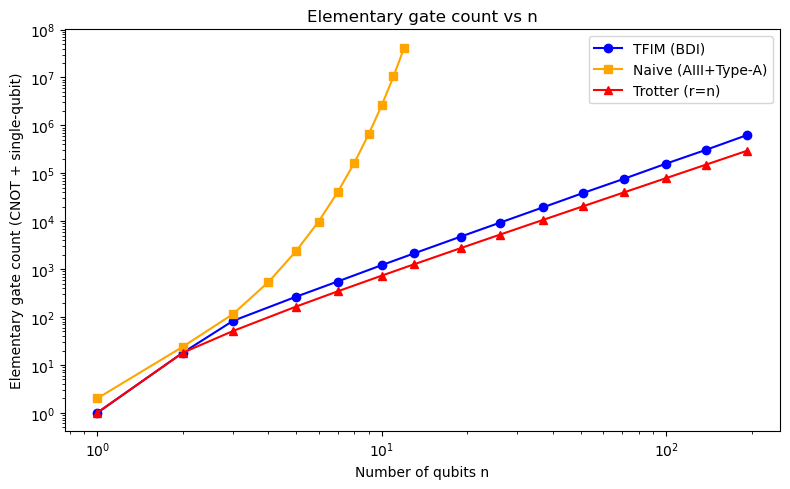

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tfim["n_qubits"], tfim["elementary_total"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(naive["n_qubits"], naive["elementary_total"], "s-", color="orange", label="Naive (AIII+Type-A)")
ax.plot(trot_rep["n_qubits"], trot_rep["elementary_total"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Elementary gate count (CNOT + single-qubit)")
ax.set_title("Elementary gate count vs n")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "gate_count_comparison.png"), dpi=150)
plt.show()


## CNOT count vs n
The hardware-relevant two-qubit gate count.

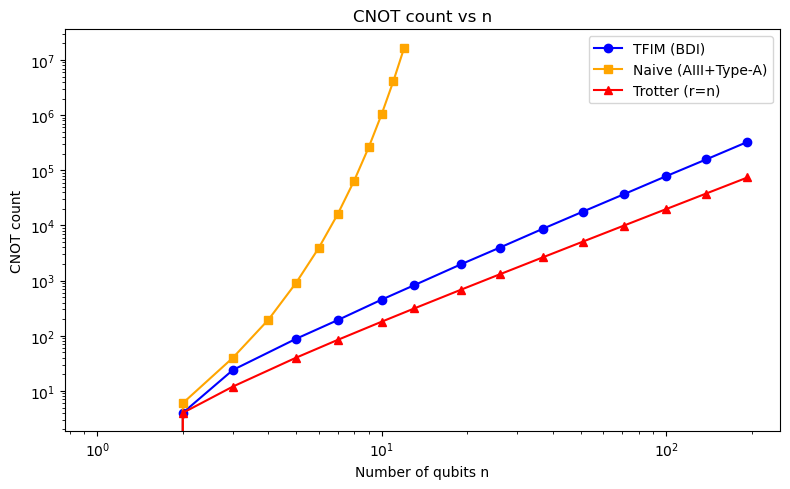

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tfim["n_qubits"], tfim["cnot"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(naive["n_qubits"], naive["cnot"], "s-", color="orange", label="Naive (AIII+Type-A)")
ax.plot(trot_rep["n_qubits"], trot_rep["cnot"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("CNOT count")
ax.set_title("CNOT count vs n")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.show()


## Decomposition time vs n
TFIM vs Naive. (Trotter's decomposition is analytic — microseconds — so it is omitted here
and characterised separately below.) Only `decomposition_time` is comparable across methods;
`total_time` includes each method's very different setup cost.

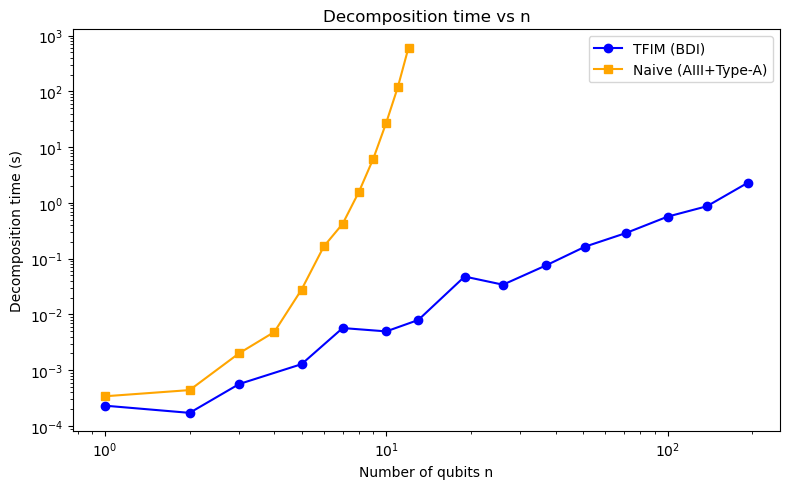

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tfim["n_qubits"], tfim["decomposition_time"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(naive["n_qubits"], naive["decomposition_time"], "s-", color="orange", label="Naive (AIII+Type-A)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Decomposition time (s)")
ax.set_title("Decomposition time vs n")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "decomposition_time_comparison.png"), dpi=150)
plt.show()


## Reconstruction error vs n
Available only for small n. **Note:** TFIM and Naive errors are *numerical* (both are exact
decompositions, so ~1e-14), whereas Trotter error is *algorithmic* (first-order Trotter is an
approximation) — they are qualitatively different and shown together only for context.

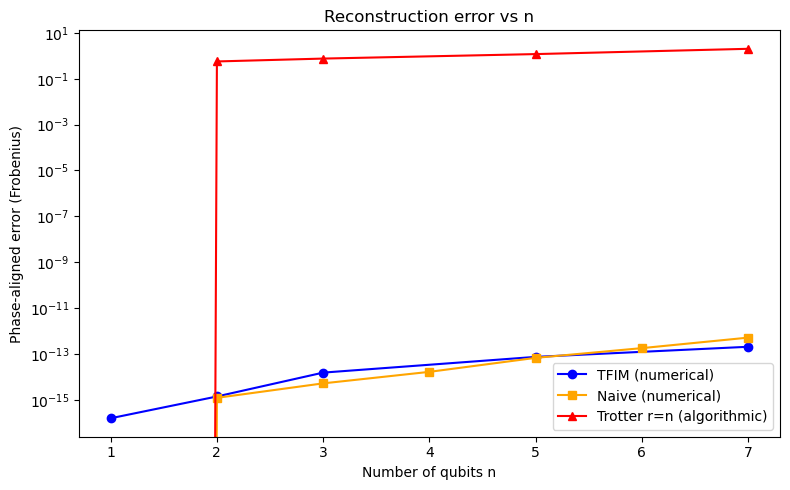

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
for df, lab, c, m in [(tfim, "TFIM (numerical)", "blue", "o"),
                      (naive, "Naive (numerical)", "orange", "s"),
                      (trot_rep, "Trotter r=n (algorithmic)", "red", "^")]:
    if df is not None and "error" in df:
        d = df.dropna(subset=["error"])
        if len(d):
            ax.plot(d["n_qubits"], d["error"], m + "-", color=c, label=lab)
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Phase-aligned error (Frobenius)")
ax.set_title("Reconstruction error vs n")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()


## Trotter characterisation: error and gate count vs Trotter steps r

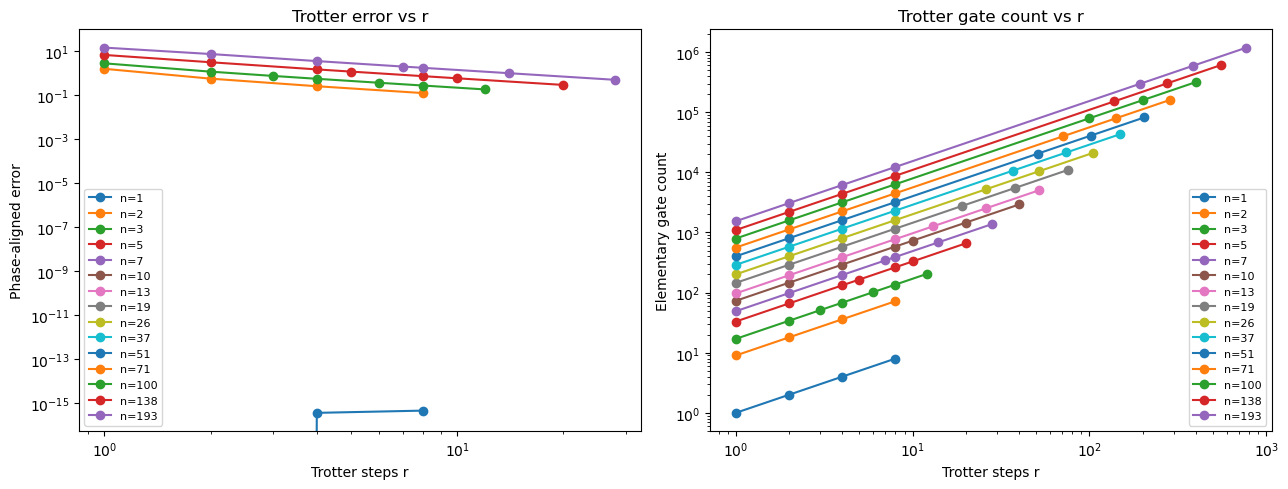

In [25]:
if trot is not None and len(trot):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    for n, g in trot.groupby("n_qubits"):
        g = g.sort_values("trotter_steps")
        ax1.plot(g["trotter_steps"], g["error"], "o-", label=f"n={n}")
        ax2.plot(g["trotter_steps"], g["elementary_total"], "o-", label=f"n={n}")

    ax1.set_xlabel("Trotter steps r")
    ax1.set_ylabel("Phase-aligned error")
    ax1.set_title("Trotter error vs r")
    ax1.set_xscale("log")
    ax1.set_yscale("log")

    ax2.set_xlabel("Trotter steps r")
    ax2.set_ylabel("Elementary gate count")
    ax2.set_title("Trotter gate count vs r")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax1.legend(fontsize=8)
    ax2.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
else:
    print("No Trotter results yet.")


## Scaling fits

**TFIM** and **Trotter** are polynomial in n, so a power law `y ~ n^b` is the right model.
**Naive** is general unitary synthesis: its cost is `O(4^n)` — *exponential* in n — so a power-law
slope is only a local descriptor (it grows with the fit range). The exponential fit `log(y) = a + c·n`
is the meaningful one for Naive.

In [26]:
def fit_power(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None
    b, _ = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
    return b

def fit_exp(x, y):
    # log(y) = a + c*n  ->  y ~ exp(c)^n; report the base exp(c)
    x = np.asarray(x, float); y = np.asarray(y, float)
    mask = (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None
    c, _ = np.polyfit(x[mask], np.log(y[mask]), 1)
    return np.exp(c)

def pw(label, b):
    print(f"{label:26s} ~ n^{b:.2f}" if b is not None else f"{label:26s}: insufficient data")

print("Polynomial (power-law) fits  y ~ n^b:")
if tfim is not None:
    pw("  TFIM  elementary gates", fit_power(tfim['n_qubits'], tfim['elementary_total']))
    pw("  TFIM  CNOT count",       fit_power(tfim['n_qubits'], tfim['cnot']))
    pw("  TFIM  decomp time",      fit_power(tfim['n_qubits'], tfim['decomposition_time']))

print()
print("Naive is O(4^n) - exponential fit  y ~ base^n:")
if naive is not None:
    be = fit_exp(naive['n_qubits'], naive['elementary_total'])
    bc = fit_exp(naive['n_qubits'], naive['cnot'])
    print(f"  Naive elementary gates ~ {be:.2f}^n   (ideal general-unitary cost ~ 4^n)" if be else "  insufficient data")
    print(f"  Naive CNOT count       ~ {bc:.2f}^n" if bc else "")
    if 'decomposition_time' in naive:
        bt = fit_exp(naive['n_qubits'], naive['decomposition_time'])
        print(f"  Naive decomp time      ~ {bt:.2f}^n" if bt else "")


Polynomial (power-law) fits  y ~ n^b:
  TFIM  elementary gates   ~ n^2.35
  TFIM  CNOT count         ~ n^2.36
  TFIM  decomp time        ~ n^1.88

Naive is O(4^n) - exponential fit  y ~ base^n:
  Naive elementary gates ~ 4.38^n   (ideal general-unitary cost ~ 4^n)
  Naive CNOT count       ~ 4.30^n
  Naive decomp time      ~ 3.86^n
